In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision import datasets, models
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from tqdm import tqdm
from PIL import Image

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


In [3]:
class TrashDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.file_list = os.listdir(root_dir)
        
        # Create a mapping for labels to numbers
        # e.g., {'cardboard': 0, 'plastic': 1}
        self.label_map = {"cardboard": 0, "plastic": 1, "glass": 2, "metal": 3, "paper": 4, "trash": 5}

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_name = self.file_list[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        # Load image
        image = Image.open(img_path).convert("RGB")
        
        # Extract label from filename: train_cardboard_000.jpg -> cardboard
        label_str = img_name.split('_')[1]
        label = self.label_map[label_str]

        if self.transform:
            image = self.transform(image)

        return image, label


# Load the base dataset (pass None for transform initially)
train_dataset = TrashDataset(root_dir='data/train', transform=None)
test_dataset = TrashDataset(root_dir='data/test',transform=None)


# EDA

In [4]:
# Define your augmentation pipeline
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),      # Resize slightly larger first
    
    # --- DATA AUGMENTATION STARTS HERE ---
    transforms.RandomResizedCrop(224),  # Randomly zoom and crop to 224x224
    transforms.RandomHorizontalFlip(),  # 50% chance to flip the image
    transforms.RandomRotation(15),      # Rotate by +/- 15 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Slight color shifts
    # --- DATA AUGMENTATION ENDS HERE ---
    
    transforms.ToTensor(),              # Convert to PyTorch Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [5]:
class ApplyTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# train dataset keeps full augmentation + normalization
train_data = ApplyTransform(train_dataset, transform=train_transform)

# Validation: no augmentations — only convert PIL -> tensor so DataLoader can batch
val_only_to_tensor = transforms.Compose([
    transforms.ToTensor(),   # no Resize/CenterCrop/Normalize here (per your request)
])

val_data = ApplyTransform(test_dataset, transform=val_only_to_tensor)

# Keep single-process workers to avoid shared-memory issues in this environment
num_workers = 0
pin_memory = False

train_loader = DataLoader(train_data, batch_size=32, shuffle=True,  num_workers=num_workers, pin_memory=pin_memory)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

print(f"Train: {len(train_data)} | Val: {len(val_data)}")

Train: 3985 | Val: 1704


Image tensor shape: torch.Size([3, 224, 224])
Label index: 0 (Name: cardboard)


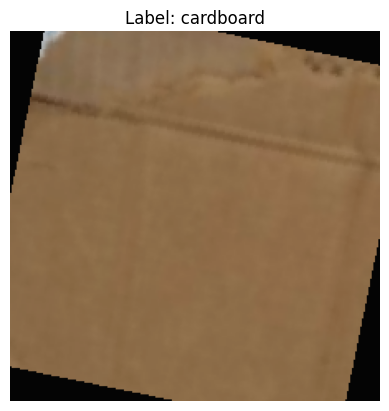

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from collections import deque

def _find_label_map(ds):
	"""
	Robustly search common wrapper attributes for a label_map dict.
	Looks at attributes like .label_map, .dataset, .subset and also inspects
	attribute values to handle custom wrappers.
	"""
	q = deque([ds])
	seen = set()
	while q:
		cur = q.popleft()
		if cur is None:
			continue
		cur_id = id(cur)
		if cur_id in seen:
			continue
		seen.add(cur_id)

		if hasattr(cur, 'label_map'):
			return getattr(cur, 'label_map')

		# common wrapper attributes that may contain the underlying dataset
		for attr in ('dataset', 'subset', 'ds', 'base', 'datasets'):
			if hasattr(cur, attr):
				try:
					val = getattr(cur, attr)
					q.append(val)
				except Exception:
					pass

		# also inspect __dict__ values (helps with some custom wrappers)
		if hasattr(cur, '__dict__'):
			for v in cur.__dict__.values():
				q.append(v)

	raise AttributeError("Could not find 'label_map' on the provided dataset or its wrappers")

# 1. Access the first item (ApplyTransform will apply transforms when indexing)
image_tensor, label_idx = train_data[0]

# 2. Locate the label_map robustly
label_map_source = _find_label_map(train_data)

# build inverse mapping: index -> name
inv_label_map = {v: k for k, v in label_map_source.items()}

# ensure label index is an int (sometimes a tensor)
label_idx_int = int(label_idx)

label_name = inv_label_map[label_idx_int]

# 3. Print stats
print(f"Image tensor shape: {image_tensor.shape}") 
print(f"Label index: {label_idx_int} (Name: {label_name})")

# 4. Display
# move to cpu if needed and convert to numpy
img_np = image_tensor.cpu().permute(1, 2, 0).numpy()

# Un-normalize
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_to_show = std * img_np + mean
img_to_show = np.clip(img_to_show, 0, 1)

plt.imshow(img_to_show)
plt.title(f"Label: {label_name}")
plt.axis('off')
plt.show()

In [7]:
from IPython.display import clear_output
import time
import copy
import torch
import numpy as np
from tqdm import tqdm

def train_model_dynamic(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience):
    since = time.time()

    # Track history
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    log_messages = [] # We will store text logs here

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    best_acc = 0.0
    epochs_no_improve = 0
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

    for epoch in range(num_epochs):
        
        # --- DYNAMIC DISPLAY SECTION ---
        clear_output(wait=True) # Clear the previous output
        
        # Print the Dashboard
        print(f"=== Training Dashboard ===")
        print(f"Epoch: {epoch+1}/{num_epochs}")
        print(f"Best Val Acc: {best_acc:.4f}")
        print(f"Patience Used: {epochs_no_improve}/{patience}")
        print(f"Time Elapsed: {(time.time() - since):.0f}s")
        print("-" * 30)
        
        # Print the last 5 lines of history so you can see the trend
        print("Recent History:")
        for msg in log_messages[-5:]:
            print(msg)
        print("-" * 30)
        # -------------------------------

        # Each epoch has a training and validation phase
        epoch_results = [] # To store temp strings for this epoch
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Progress bar
            iter_bar = tqdm(dataloader, desc=phase, leave=False)
            
            for inputs, labels in iter_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                # Update progress bar with current loss
                iter_bar.set_postfix(loss=loss.item())

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            # Save result string
            result_msg = f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}'
            epoch_results.append(result_msg)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                scheduler.step(epoch_loss)

                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), 'best_model.pth')
                    epoch_results.append(" [Saved Best Model!]")
                else:
                    epochs_no_improve += 1
        
        # Add this epoch's results to the log
        log_messages.append(f"Ep {epoch+1}: " + " | ".join(epoch_results))

        # Early Stopping check
        if epochs_no_improve >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs!')
            break

    # Final Summary
    clear_output(wait=True)
    print("=== Training Complete ===")
    print(f"Total Time: {(time.time() - since) // 60:.0f}m {(time.time() - since) % 60:.0f}s")
    print(f"Best Val Acc: {best_acc:.4f}")
    
    model.load_state_dict(best_model_wts)
    return model, history, best_acc


In [8]:
model = models.resnet50(weights='DEFAULT')

# Robustly get the label_map (handles wrappers like ApplyTransform)
label_map_source = _find_label_map(train_data)
num_classes = len(label_map_source)

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_model, history, best_acc = train_model_dynamic(model, train_loader, val_loader, criterion, optimizer, num_epochs=1000, patience=15)

print(f"Training finished with best validation accuracy: {best_acc:.4f}")

=== Training Dashboard ===
Epoch: 1/1000
Best Val Acc: 0.0000
Patience Used: 0/15
Time Elapsed: 0s
------------------------------
Recent History:
------------------------------


KeyboardInterrupt: 

In [ ]:
# Plotting the loss curves
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(f"Training finished with best validation accuracy: {best_acc:.4f}")

In [ ]:
# outputting images the model got wrong from the test set
model.eval()
incorrect_images = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                incorrect_images.append((inputs[i].cpu(), labels[i].cpu(), preds[i].cpu()))
# Prepare inverse label map robustly
try:
    label_map_for_display = _find_label_map(train_data)
except Exception:
    # fallback to a hardcoded/default mapping if necessary
    label_map_for_display = getattr(train_data, 'label_map', None) or {0:'cardboard',1:'plastic',2:'glass',3:'metal',4:'paper',5:'trash'}
inv_label_map = {v: k for k, v in label_map_for_display.items()}

# Display some incorrect predictions
num_to_display = min(5, len(incorrect_images))
for i in range(num_to_display):
    img_tensor, true_label, pred_label = incorrect_images[i]

    # Un-normalize the image for display
    img_to_show = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_to_show = std * img_to_show + mean
    img_to_show = np.clip(img_to_show, 0, 1)

    plt.imshow(img_to_show)
    plt.title(f"True: {inv_label_map[int(true_label)]} | Pred: {inv_label_map[int(pred_label)]}")
    plt.axis('off')
    plt.show()